
### Tasks

**Remember this is a real research example, not an exam! You're welcome (and encouraged actually!) to use all the tutorials/answers/hack you find online!**


1) Read in `solutions/transient.npy`. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

2) One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as:

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.

Code this burst model, and code a likelihood function for this data with the burst model. *Hint: This is similar in spirit to the likelihood when fitting polynomials to data, except now $x$ is time, and the polynomial model is now the burst model.* 

3) Using one of the MCMC sampler that we looked at in class (`emcee`, `pymc`), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{b,A,t_0,\alpha\}$. You must decide on how many samples are appropriate for running your MCMC. For your priors, make them $b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$ (careful: uniform in $\ln\alpha$, not $\alpha$).

4) Perform an appropriate check to burn-in your chain, and thin the chain by selecting only points every auto-correlation length. If you are left with a small number of samples after thinning then you may need to run your MCMC for longer in (3).

5) Make a corner plot of the $4$-D parameter space, with labels, $[68,95]\%$ credible levels and quantiles, and titles.

6) Now choose $100$ samples randomly from your burned, thinned chain and plot the $100$ corresponding burst time-series on a figure along with the original data. You may want to choose a transparency for these $100$ burst curves that allows you to see everything nicely. These are showing the posterior spread of model solutions that are consistent with the data.

7) For each parameter, find the median and 90% credible region of the marginalized distribution and quote results as, for instance, $t_0=X^{+Y}_{-Z}$ 



# emcee try

In [14]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
from scipy.stats import expon, norm, loguniform
import corner
import dynesty

In [15]:
#import data
data_path = '/home/matti/uni/astrostatistics_bicocca_2026/solutions/transient.npy'

data = np.load(data_path)

x = data[:, 0]
y = data[:, 1]
yerr = data[:, 2]

<ErrorbarContainer object of 3 artists>

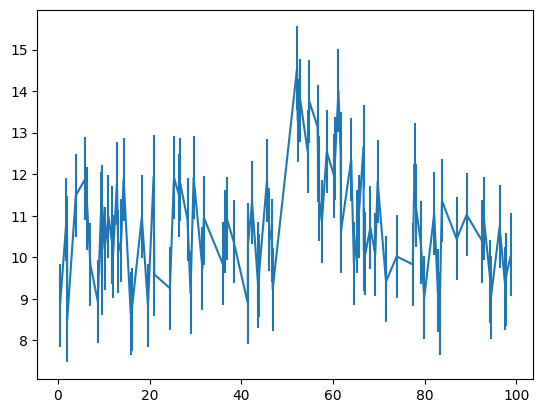

In [16]:
plt.errorbar(x, y, yerr)

In [17]:
# define a likelihood

def model(x, a, b, alpha, t0) : 
    exponent = -alpha * (x - t0)
    # exponent = np.clip(exponent, -700, 700) 
    return np.where(x<t0, b,  b + a * np.exp( exponent ))

#likelihood
# def like ( y, x, a, b, alpha, t0):
#     return (norm.pdf(loc = (model(x, alpha, a, b, t0) - y), scale = 1))

# cose per emcee
ndim = 4
nwalkers = 16
nsteps = 100000
burn = 30000

# mi serve prior, le singole distribuzioni le considero indipendenti --> posso moltiplicarle per ottenere prior
prior_a = 1/50
prior_b = 1/50
prior_t0 = 1/100
#log(alpha) is uniform [-5, 5], so alpha is [e**-5, e**5]


#credo che in principio io possa esprimere il tutto solo in base a -log(alpha) poichè è l'unico che varia davvero,
#in teoria MCMC non tengono conto dei prior uniformi
def log_prior(theta):
    a, b, alpha, t0 = theta
        # Since ln(alpha) is uniform, the prior probability P(alpha) is proportional to 1/alpha
        # log(1/alpha) = -log(alpha)
    # Check boundaries
    if not (0 < a <= 50 and 0 < b <= 50 and 0 < t0 <= 100 and (np.exp(-5)) <= alpha <= (np.exp(5))):
        return -np.inf # Outside bounds means zero probability -> log is -inf
    # log_prob += np.log(1/50) + np.log(1/50) + np.log(1/100)  # uniform priors (optional)
    return - np.log(alpha) #log_sum
    

def myLogPosterior(theta, x, y, sigma_y):
    a, b, log_alpha, t0 = theta
    model_val = model(x, a, b, log_alpha, t0)
    log_likelihood = -0.5 * np.sum(((y - model_val)**2 / sigma_y**2))
    log_p = log_prior(theta)
    return log_likelihood + log_p


# np.random.seed(1520) #numero a caso
starting_guesses = np.random.random((nwalkers, ndim))
starting_guesses[:, 0] = np.random.uniform(10, 40, nwalkers)   # a
starting_guesses[:, 1] = np.random.uniform(10, 40, nwalkers)   # b
starting_guesses[:, 2] = np.random.uniform(0.001, 10, nwalkers) # alpha
starting_guesses[:, 3] = np.random.uniform(45, 55, nwalkers) #t0 ,vedo un "bumpino" at x = 50


# the function call where all the work happens: 
sampler = emcee.EnsembleSampler(nwalkers, ndim, myLogPosterior, args=(x, y, yerr))
sampler.run_mcmc(starting_guesses, nsteps, progress = True)
 
# sampler.chain is of shape (nwalkers, nsteps, ndim)
# throw-out the burn-in points and reshape:
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)
#circa 1-2 min



  0%|          | 0/100000 [00:00<?, ?it/s]/tmp/ipykernel_16634/4270581938.py:6: RuntimeWarning: overflow encountered in exp
  return np.where(x<t0, b,  b + a * np.exp( exponent ))
/tmp/ipykernel_16634/4270581938.py:6: RuntimeWarning: overflow encountered in multiply
  return np.where(x<t0, b,  b + a * np.exp( exponent ))
/tmp/ipykernel_16634/4270581938.py:41: RuntimeWarning: overflow encountered in square
  log_likelihood = -0.5 * np.sum(((y - model_val)**2 / sigma_y**2))
  0%|          | 304/100000 [00:00<01:28, 1126.10it/s]/home/matti/uni/lab/myenv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
100%|██████████| 100000/100000 [01:03<00:00, 1563.61it/s]


In [18]:
print(sampler.chain.shape) #chain structure: 16 walkers, 100000 steps, 4 variables
print(len(emcee_trace.flatten()))
tau = sampler.get_autocorr_time()

(16, 100000, 4)
4480000


In [19]:
print(tau)
thin = np.max([int(x + 1) for x in tau]) #il thinning deve avvenire con una sola autocorrelation lenght
emcee_trace1 = sampler.get_chain(discard = burn, thin = thin, flat = True)
print(emcee_trace.shape)

[316.91986001  70.90655083 399.61056957 167.32107867]
(1120000, 4)


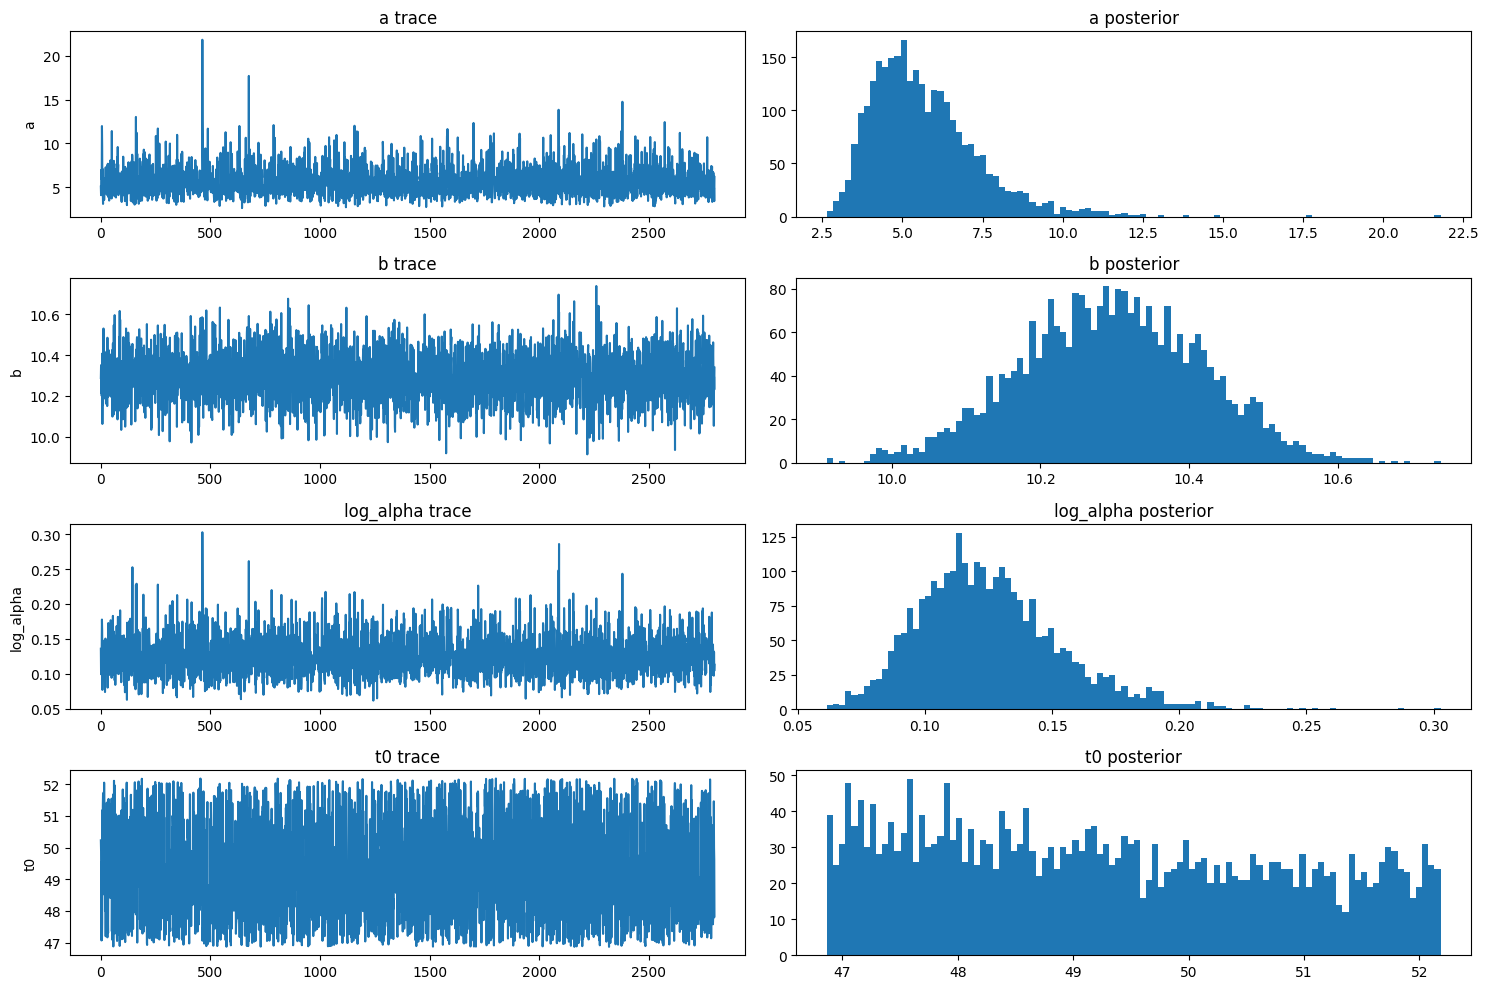

In [20]:
a = emcee_trace1[:, 0]
b = emcee_trace1[:, 1]
log_alpha = emcee_trace1[:, 2]
t0 = emcee_trace1[:, 3]
fig, ax = plt.subplots(figsize = (15, 10), ncols = 2, nrows = 4)
ax[0, 0].plot(np.arange(len(a)), a)
ax[0, 0].set_title("a trace")
ax[0, 0].set_ylabel("a")
ax[0, 1].hist(a, bins=100)
ax[0, 1].set_title("a posterior")

ax[1, 0].plot(np.arange(len(b)), b)
ax[1, 0].set_title("b trace")
ax[1, 0].set_ylabel("b")
ax[1, 1].hist(b, bins=100)
ax[1, 1].set_title("b posterior")

ax[2, 0].plot(np.arange(len(log_alpha)), log_alpha)
ax[2, 0].set_title("log_alpha trace")
ax[2, 0].set_ylabel("log_alpha")
ax[2, 1].hist(log_alpha, bins=100)
ax[2, 1].set_title("log_alpha posterior")

ax[3, 0].plot(np.arange(len(t0)), t0)
ax[3, 0].set_title("t0 trace")
ax[3, 0].set_ylabel("t0")
ax[3, 1].hist(t0, bins=100)
ax[3, 1].set_title("t0 posterior")

plt.tight_layout()


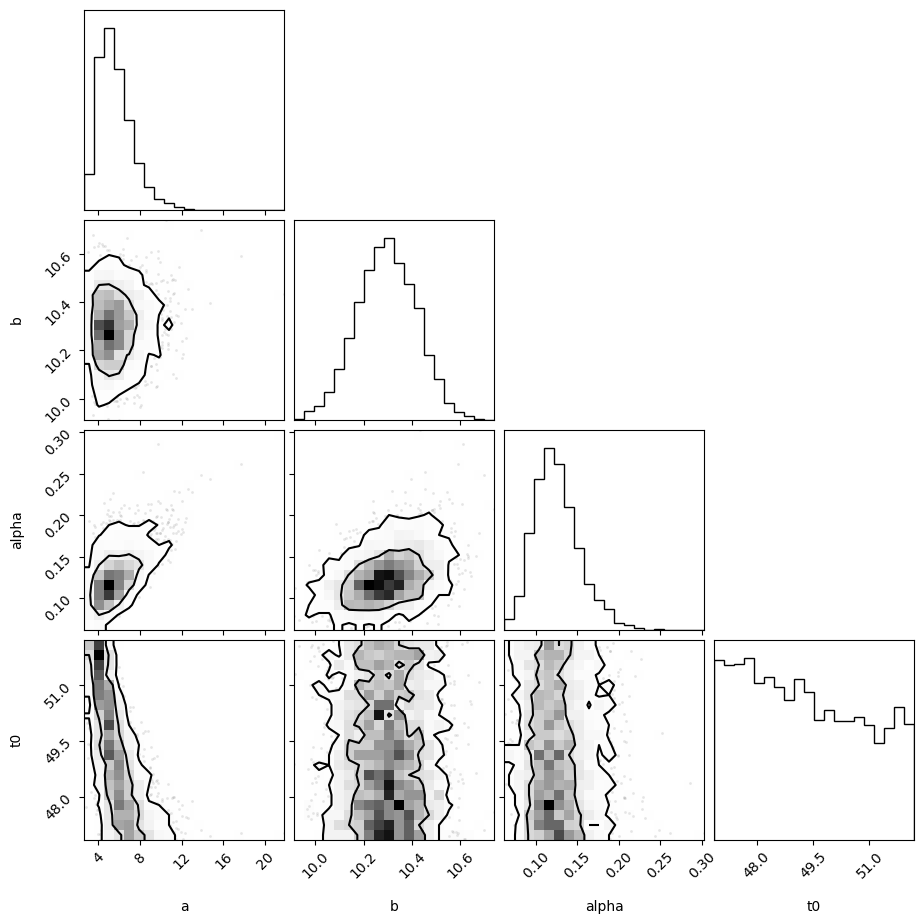

In [21]:
label = ('a', 'b', 'alpha', 't0')
fig = corner.corner(emcee_trace1, labels = label, levels = [0.68, 0.95])

<ErrorbarContainer object of 3 artists>

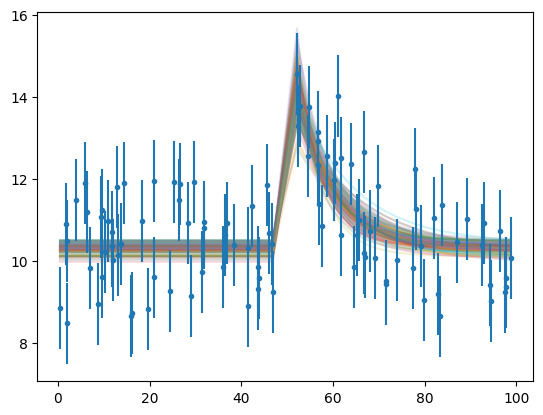

In [ ]:
np.zeros
for i in range (100):
    param = emcee_trace1[np.random.randint(len(emcee_trace1))]
    plt.plot(x, model(x, *param), alpha=0.2)
plt.errorbar(x, y, yerr, fmt='.')

In [37]:
mean_param = np.mean(emcee_trace1, axis=0)
percentile_5_param = np.percentile(emcee_trace1, 5, axis=0)
percentile_95_param = np.percentile(emcee_trace1, 95, axis=0)

print(f"Mean: {mean_param}")
print(f"5th percentile (mean - 45%): {percentile_5_param}")
print(f"95th percentile (mean + 45%): {percentile_95_param}")


Mean: [ 5.68433855 10.29489267  0.125245   49.27279274]
5th percentile (mean - 45%): [ 3.5886229  10.09371445  0.08608582 47.07583101]
95th percentile (mean + 45%): [ 8.78063373 10.49298749  0.1755482  51.85618566]


## nested sampling try

Time to get your hands dirty.  The transient Universe

*(exam guidelines available [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/exams.md))*



Let's go back to our previous example on the astrophysical transient.


8) Fit the same model from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

7) Another possible model that may explain the data is a Gaussian profile described by:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

Fit this model usign nested sampling and reasonable priors (this time is up to you to decide...)

9) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

In [23]:

def model(x, a, b, alpha, t0) : 
    exponent = -alpha * (x - t0)
    exponent = np.clip(exponent, None, 700) 
    return np.where(x<t0, b,  b + a * np.exp( exponent ))

def myloglike(theta):
    a, b, alpha, t0 = theta
    model_val = model(x, a, b, alpha, t0)
    log_likelihood = -0.5 * np.sum(((y - model_val)**2 / yerr**2))
    return log_likelihood

def prior_transformation(u):
    a = u[0] * 50
    b = u[1] * 50
    alpha  = np.exp(10.0 * u[2] - 5.0)
    t0 = u[3] * 100
    return [a, b, alpha, t0]
    
sampler = dynesty.NestedSampler(loglikelihood= myloglike, ndim = 4, prior_transform=prior_transformation, sample = 'rwalk')
sampler.run_nested()

0it [00:00, ?it/s]

7489it [00:12, 605.56it/s, +500 | bound: 14 | nc: 1 | ncall: 154456 | eff(%):  5.189 | loglstar:   -inf < -48.759 <    inf | logz: -62.942 +/-  0.165 | dlogz:  0.001 >  0.509]


In [24]:
sresults = sampler.results

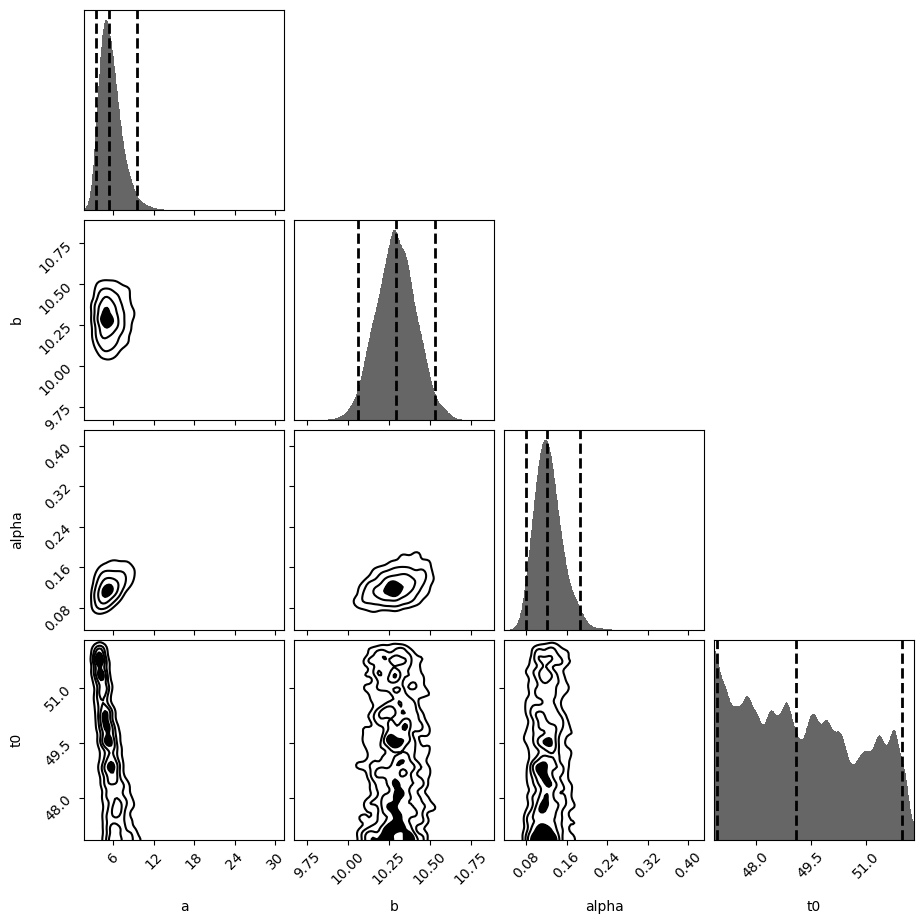

In [30]:
from dynesty import plotting as dyplot
fig, ax = dyplot.cornerplot(sresults, labels = label)

Figure 2. An example highlighting the behavior of a Static Nested Sampling run in dynesty. See §2 for additional details. Top: The
number of live points as a function of prior volume X. Snapshots of their their distribution (purple) with respect to the current bounds
(gray; see §4.1) are highlighted in several insets. The number of live points remains constant until sampling terminates, at which point
we add the final live points one-by-one to the samples. Top-middle: The (normalized) likelihood limit L/Lmax associated with a the prior
volume X(L) in the top panel. This increases monotonically as we sample increasingly smaller regions of the prior. Bottom-middle: The
importance weight PDF p(X), roughly divided into regions dominated by the prior volume (dX is large, L(X) is small; yellow), posterior
mass (dX and L(X) are comparable; orange), and likelihood density (dX is small, L(X) is large; red). The posterior mass is the most
important for posterior estimation, while evidence estimation also depends on the prior volume. Bottom: The estimated evidence Z( ˆ X)
(blue line) and its 1, 2, and 3-sigma errors (blue shaded). The true value is shown in red.

from https://arxiv.org/pdf/1904.02180

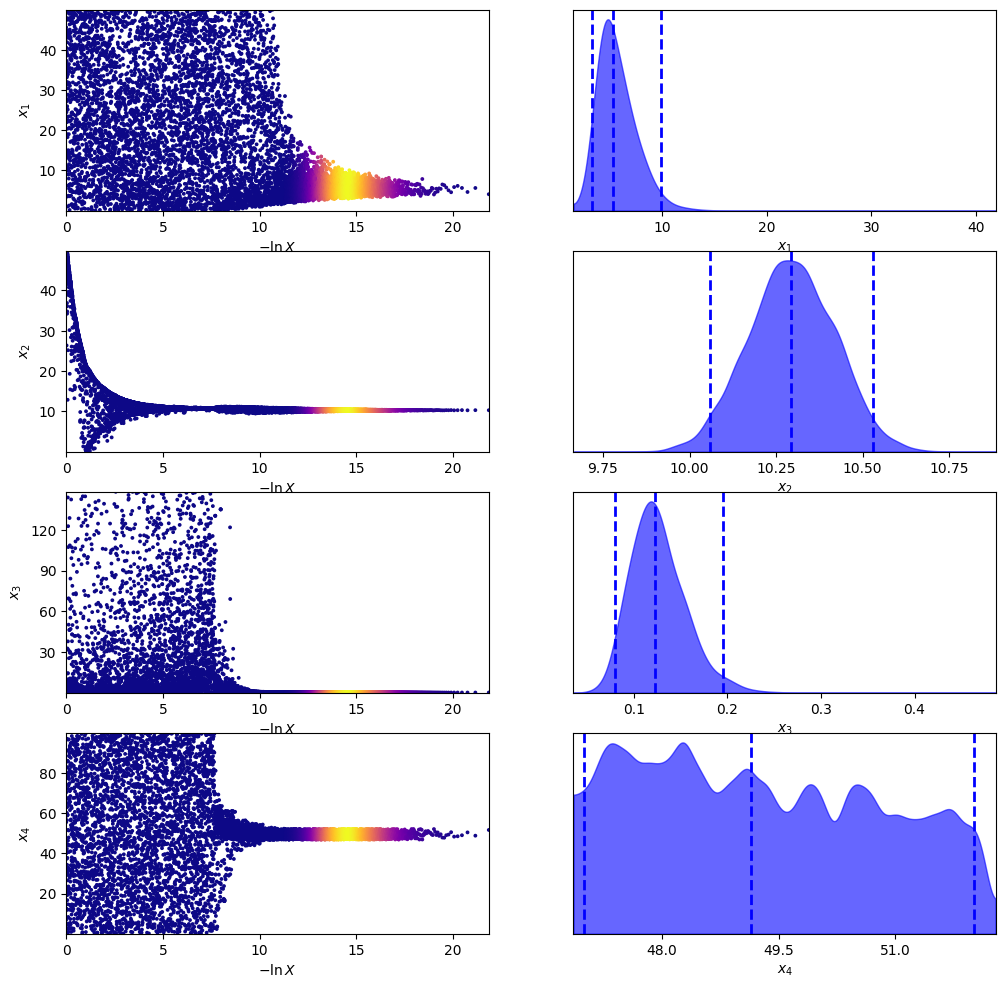

In [ ]:
tfig, taxes = dynesty.plotting.traceplot(sresults)

In [31]:
#now i try with gaussian model:
def model2(theta, x):
    a, b, sigma, t0 = theta
    return b + a * np.exp(-(x - t0)**2 / (2 * sigma**2))


#scelgo priors uniformi
def prior_transformation2(u):
    a = u[0] * 15
    b = u[1] * 15
    sigma = u[2] * 30
    t0 = u[3] * 70

sampler2 = dynesty.NestedSampler(loglikelihood= myloglike, ndim = 4, prior_transform=prior_transformation, sample = 'rwalk')
sampler2.run_nested()

7793it [00:12, 629.13it/s, +500 | bound: 16 | nc: 1 | ncall: 162411 | eff(%):  5.122 | loglstar:   -inf < -48.760 <    inf | logz: -63.560 +/-  0.169 | dlogz:  0.001 >  0.509]


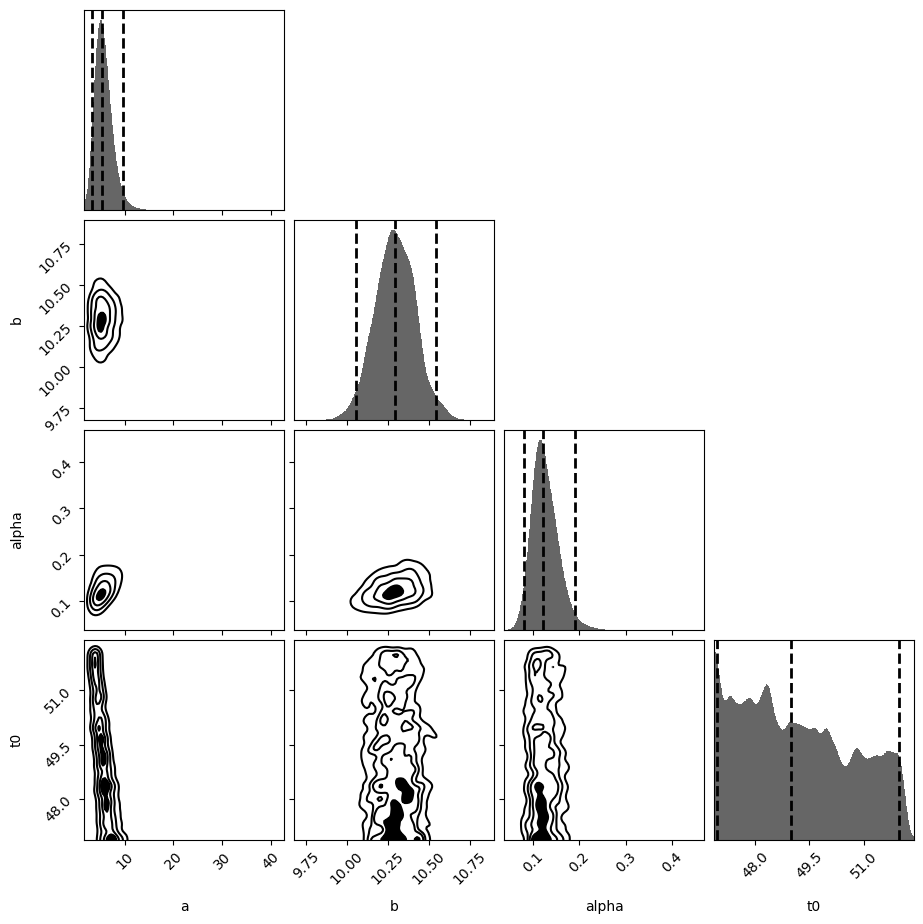

In [32]:
sresults2 = sampler2.results
fig, ax = dyplot.cornerplot(sresults2, labels = label)


## evidence compare

In [33]:
logz = sresults.logz[-1]        # The final estimated ln(Z)
logz_err = sresults.logzerr[-1]  # The numerical uncertainty on ln(Z)
logz2 = sresults2.logz[-1]        # The final estimated ln(Z)
logz_err2 = sresults2.logzerr[-1]  # The numerical uncertainty on ln(Z)

In [38]:
print('bayes factor:', abs(logz2 - logz))
print('Jeffreys scale: Barely worth mentioning - not worth more than a bare mention')

bayes factor: 0.6185674001368255
Jeffreys scale: Barely worth mentioning - not worth more than a bare mention
